## 1️⃣ Initial Setup and Dataset Loading

**Task**: Load the Flickr8k dataset and prepare image-caption pairs for training.

**Requirements**:
- Download and organize the Flickr8k dataset
- Load image files and corresponding captions
- Create proper dataset splits (train/dev/test)
- Set up image transformations and text tokenizationnization

In [ ]:
# Useful imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import AutoTokenizer, DistilBertModel, get_cosine_schedule_with_warmup

import numpy as np
import time
import matplotlib.pyplot as plt
from PIL import Image
import kagglehub
import os
from collections import defaultdict
from tqdm.auto import tqdm
import warnings
from IPython.display import clear_output, display
import time # Import the time module
import seaborn as sns
import random
from collections import Counter
import re

# This is needed for the file upload widget in Colab
from google.colab import files
# For evaluation metrics
from sklearn.metrics import classification_report

In [ ]:
# Global variables
SEED = 42
BATCH_SIZE = 32
NUM_EPOCHS = 10  # Increased slightly, with early stopping
HEAD_LR = 5e-5  # Lowered to reduce overfitting
BACKBONE_LR = 5e-7  # Lowered further
WEIGHT_DECAY = 0.1  # Increased for stronger regularization
PATIENCE = 3  # For early stopping

In [ ]:
# SETUP AND CONFIGURATION

def setup_environment(seed=SEED):
    """Initializes device, sets random seeds, and suppresses warnings."""
    warnings.filterwarnings("ignore") # Suppress minor warnings to keep the output clean
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    print(f"Using device: {device}")
    return device

# Initialize the environment and get the device
device = setup_environment()

Using device: cuda


In [ ]:
# Kaggle Authentication
# Check if the Kaggle API token ('kaggle.json') exists
# If not, it prompts the user to upload it. This is necessary for downloading datasets from Kaggle.
print("\nChecking for Kaggle API token...")
if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Please upload your Kaggle API token (kaggle.json)")
    try:
        # Use Colab's file upload widget
        uploaded = files.upload()
        for fn in uploaded.keys():
            print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
        # Create the .kaggle directory and move the token into it
        os.makedirs('/root/.kaggle', exist_ok=True)
        os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
        os.chmod('/root/.kaggle/kaggle.json', 600)
        print("Kaggle API token configured successfully.")
    except Exception as e:
        print(f"An error occurred during Kaggle authentication: {e}")
        print("Please ensure you have uploaded 'kaggle.json' and accepted the dataset terms online.")
else:
    print("Kaggle API token already exists.")

# Download Dataset & Find Paths
# downloads the Flickr8k dataset using the Kaggle Hub library and locates the necessary files
print("\nDownloading Flickr8k dataset from Kaggle Hub...")
try:
    download_path = kagglehub.dataset_download("ming666/flicker8k-dataset")
    print(f"Dataset downloaded to: {download_path}")

    def find_file(root_path, file_to_find):
        for dirpath, _, filenames in os.walk(root_path):
            if file_to_find in filenames:
                return os.path.join(dirpath, file_to_find)
        return None

    # Automatically find the paths to the captions and image split files
    print("\nSearching for dataset files automatically...")
    CAPTIONS_FILE = find_file(download_path, 'Flickr8k.token.txt')
    TRAIN_FILE = find_file(download_path, 'Flickr_8k.trainImages.txt')
    DEV_FILE = find_file(download_path, 'Flickr_8k.devImages.txt')
    TEST_FILE = find_file(download_path, 'Flickr_8k.testImages.txt')
    # Find the main image directory by locating a sample image and getting its parent directory
    sample_image_path = find_file(download_path, '1000268201_693b08cb0e.jpg')
    IMAGES_DIR = os.path.dirname(sample_image_path) if sample_image_path else None

    # Verify that all essential files were found
    if not all([CAPTIONS_FILE, TRAIN_FILE, IMAGES_DIR]):
        raise FileNotFoundError("Could not auto-locate critical dataset files!")

    print("✅ All required files and directories found successfully!")
    print(f"  Images directory: {IMAGES_DIR}")
    print(f"  Captions file:    {CAPTIONS_FILE}")

# Error handling in case the download or file search fails
except Exception as e:
    print(f"--- DATA LOADING FAILED ---")
    print(f"Error: {e}")
    print("\nTroubleshooting:")
    print("1. Did you accept the rules on the Kaggle dataset page?")
    print("2. Is your kaggle.json API token correct and active?")
    download_path = None # Prevent subsequent code from running


Checking for Kaggle API token...
Please upload your Kaggle API token (kaggle.json)


Saving kaggle.json to kaggle.json
User uploaded file "kaggle.json" with length 64 bytes
Kaggle API token configured successfully.

Dataset downloaded to: /kaggle/input/flicker8k-dataset

Searching for dataset files automatically...
✅ All required files and directories found successfully!
  Images directory: /kaggle/input/flicker8k-dataset/Flickr8k_Dataset/Flicker8k_Dataset
  Captions file:    /kaggle/input/flicker8k-dataset/Flickr8k_text/Flickr8k.token.txt


--- 📊 EDA: Sample Images and Captions ---
--- 📊 EDA: Sample Images and Captions ---


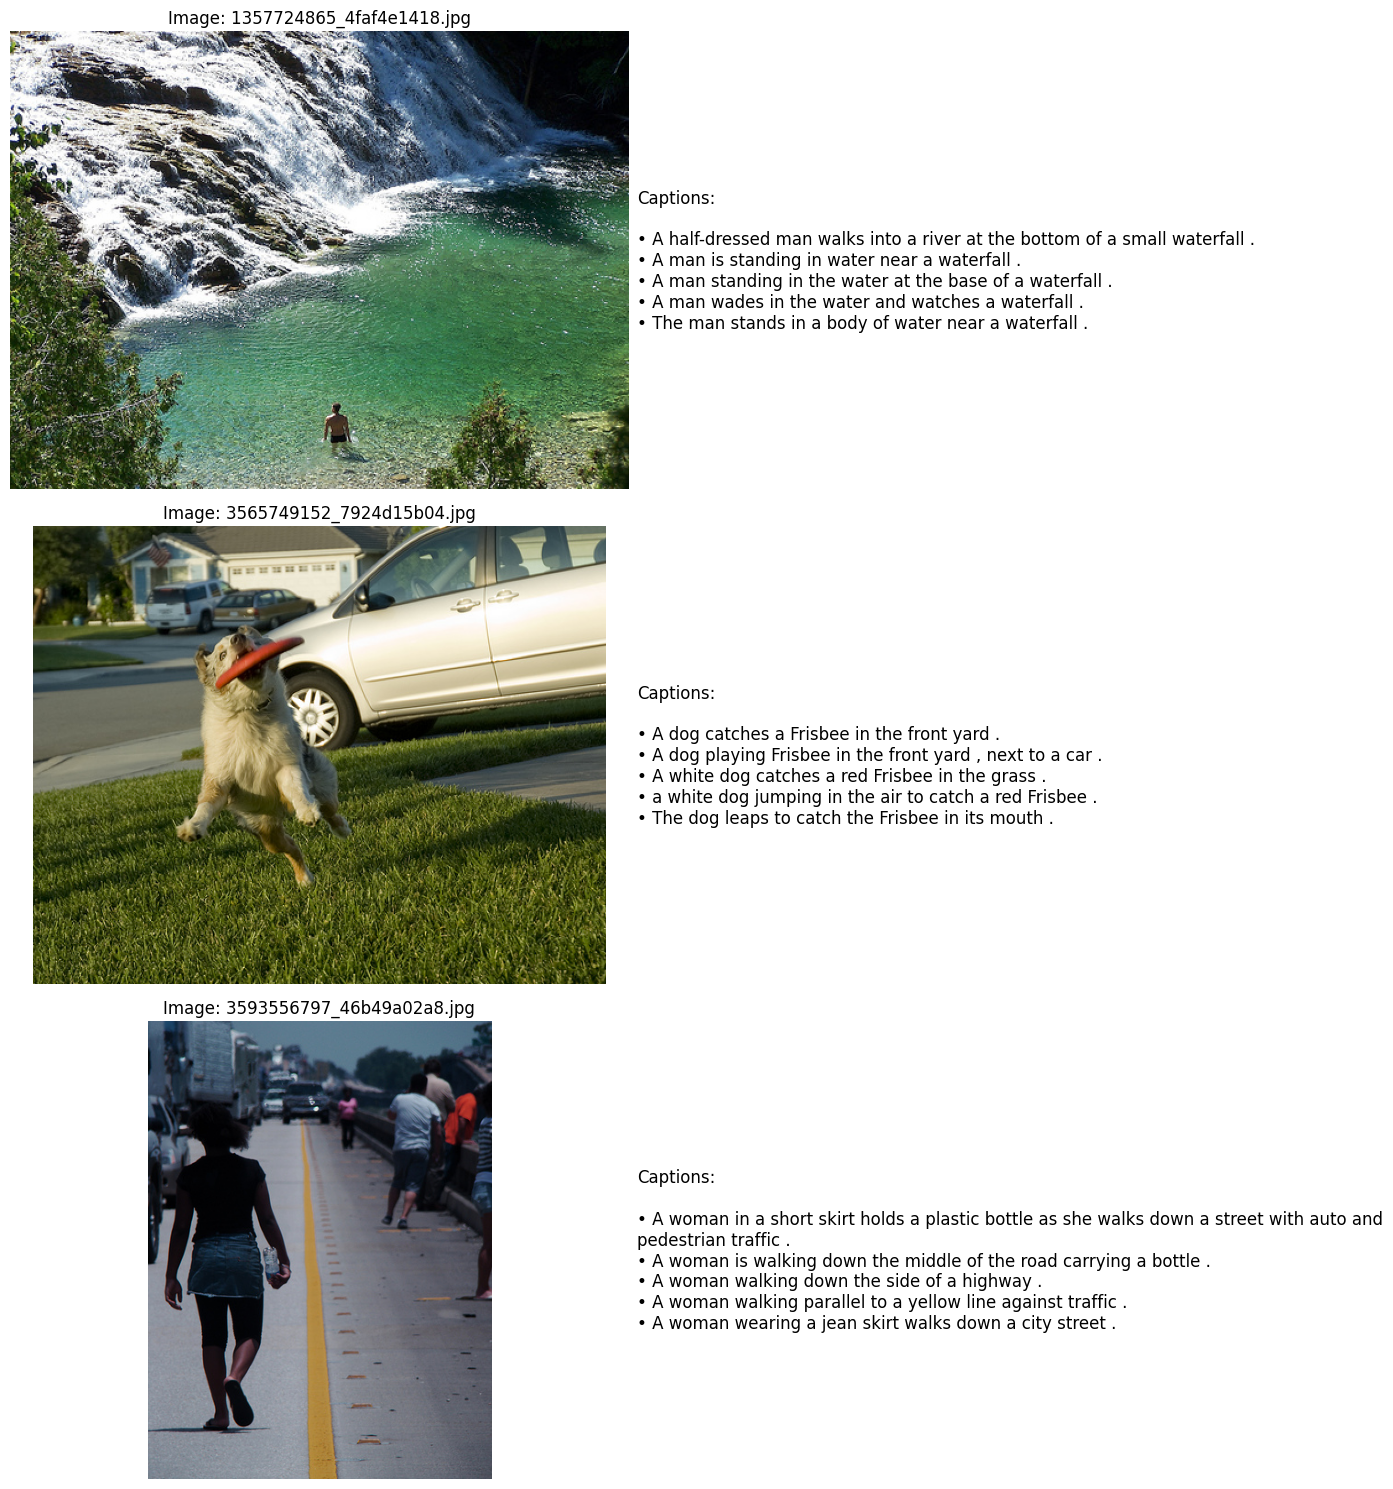


--- 📊 EDA: Caption Length Distribution ---


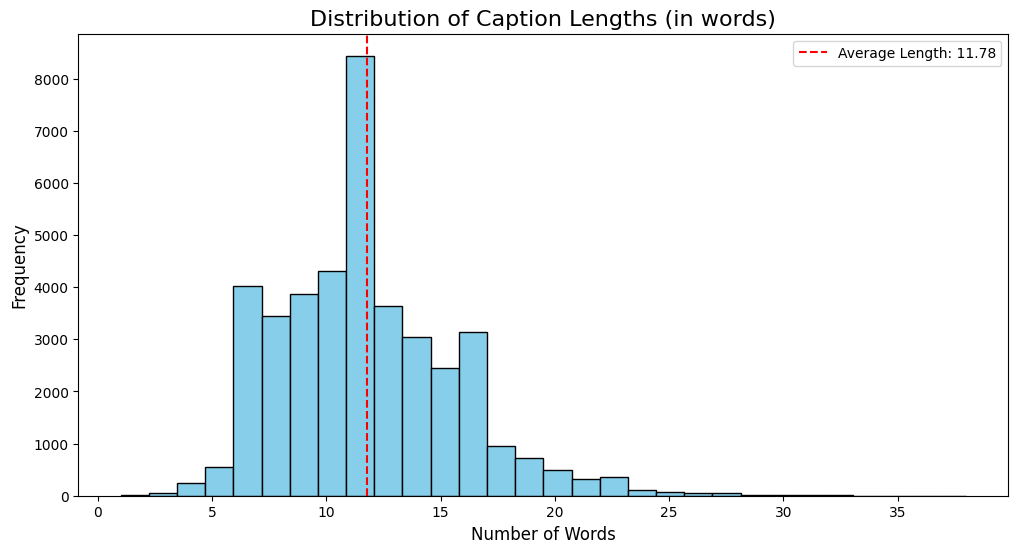


--- 📊 EDA: Most Common Words in Captions ---


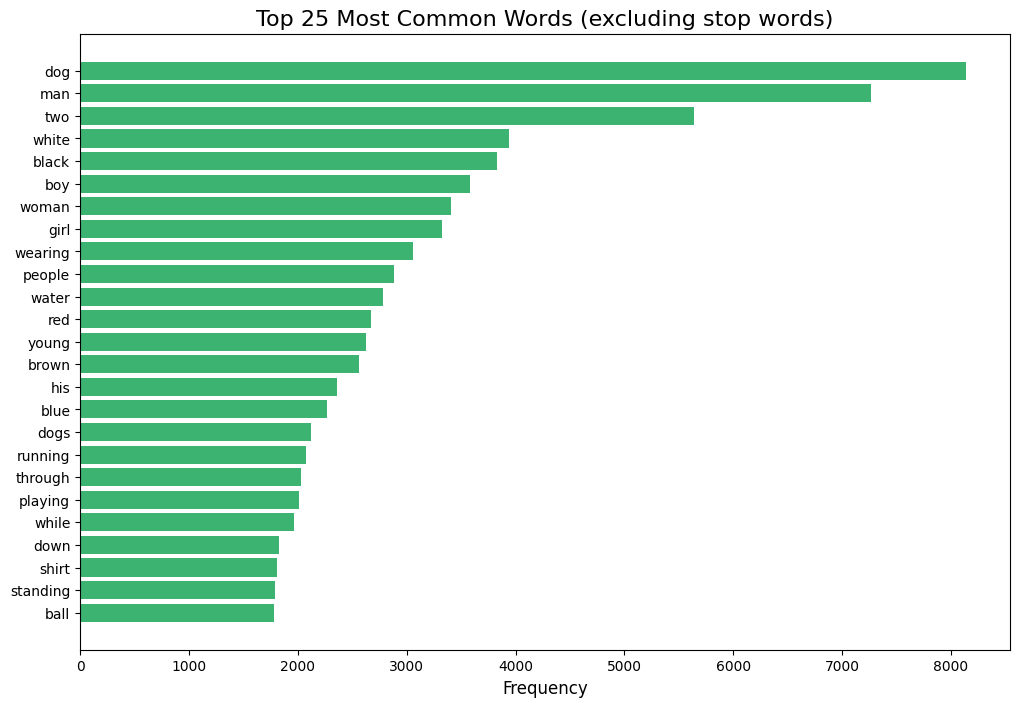

In [ ]:
# EXPLORATORY DATA ANALYSIS (EDA)
# Explore and visualize the dataset

def load_captions_for_eda(captions_file):
    """Loads all captions into a dictionary mapping image filenames to a list of their captions."""
    # defaultdict(list) simplifies appending: if a key doesn't exist, it's created with an empty list.
    captions_dict = defaultdict(list)
    with open(captions_file, 'r') as f:
        for line in f:
            parts = line.strip().split('\t', 1)
            if len(parts) == 2:
                img_id, caption = parts
                # The image ID in the file is like 'image.jpg#0' but only need the 'image.jpg' part
                img_name = img_id.split('#')[0]
                captions_dict[img_name].append(caption.strip())
    return captions_dict

def eda_show_samples(image_dir, filenames, captions, num_samples=3):
    """Displays a random selection of images alongside their corresponding captions."""
    print("--- 📊 EDA: Sample Images and Captions ---")
    print("--- 📊 EDA: Sample Images and Captions ---")
    sample_filenames = random.sample(list(filenames), num_samples)
    plt.figure(figsize=(15, num_samples * 5))
    for i, filename in enumerate(sample_filenames):
        img_path = os.path.join(image_dir, filename)
        # Display the image
        ax = plt.subplot(num_samples, 2, 2 * i + 1)
        image = Image.open(img_path).convert("RGB")
        ax.imshow(image)
        ax.set_title(f"Image: {filename}")
        ax.axis('off')
        # Display the captions as text
        ax = plt.subplot(num_samples, 2, 2 * i + 2)
        captions_text = "Captions:\n\n" + "\n".join([f"• {c}" for c in captions[filename]])
        ax.text(0, 0.5, captions_text, ha='left', va='center', fontsize=12, wrap=True)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

def eda_caption_lengths(captions):
    """Plots a histogram of the caption lengths to understand their distribution."""
    print("\n--- 📊 EDA: Caption Length Distribution ---")
    # Create a list of the word count for every caption in the dataset
    caption_lengths = [len(caption.split()) for img_captions in captions.values() for caption in img_captions]
    plt.figure(figsize=(12, 6))
    plt.hist(caption_lengths, bins=30, color='skyblue', edgecolor='black')
    plt.title('Distribution of Caption Lengths (in words)', fontsize=16)
    plt.xlabel('Number of Words', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    # Add a vertical line for the average length
    avg_len = np.mean(caption_lengths)
    plt.axvline(avg_len, color='red', linestyle='--', label=f'Average Length: {avg_len:.2f}')
    plt.legend()
    plt.show()

def eda_word_frequency(captions, num_words=25):
    """Finds and plots the most common words in the captions, excluding common stop words."""
    print("\n--- 📊 EDA: Most Common Words in Captions ---")
    # A simple set of stop words to exclude from the analysis
    stop_words = set("a an the is are was were in on at to of for and with by from this that it he she they i you my your".split())
    all_words = []
    for img_captions in captions.values():
        for caption in img_captions:
            # Preprocess: remove punctuation, convert to lowercase, and split into words
            words = re.sub(r'[^\w\s]', '', caption.lower()).split()
            all_words.extend([word for word in words if word not in stop_words])
    # Count the frequency of each word
    word_counts = Counter(all_words)
    most_common = word_counts.most_common(num_words)
    words, counts = zip(*most_common)
    # Plot the results as a horizontal bar chart
    plt.figure(figsize=(12, 8))
    plt.barh(words, counts, color='mediumseagreen')
    plt.title(f'Top {num_words} Most Common Words (excluding stop words)', fontsize=16)
    plt.xlabel('Frequency', fontsize=12)
    plt.gca().invert_yaxis()
    plt.show()

# Run EDA functions if the dataset was loaded successfully
if 'CAPTIONS_FILE' in locals() and CAPTIONS_FILE:
    temp_captions = load_captions_for_eda(CAPTIONS_FILE)
    temp_train_files = {line.strip() for line in open(TRAIN_FILE)}
    eda_show_samples(IMAGES_DIR, temp_train_files, temp_captions)
    eda_caption_lengths(temp_captions)
    eda_word_frequency(temp_captions)
else:
    print("Skipping EDA because data was not loaded.")

In [ ]:
# Dataset implementation
# This cell defines the custom PyTorch Dataset and creates DataLoaders

class Flickr8kDataset(Dataset):
    """Custom PyTorch Dataset for the Flickr8k data."""
    def __init__(self, image_dir, captions_file, split_file, tokenizer, max_length=77, transform=None):
        super().__init__()
        self.image_dir = image_dir
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.transform = transform

        # Load the image filenames for the specific split (train, dev, or test)
        with open(split_file, 'r') as f:
            self.image_files = {line.strip() for line in f.readlines()}

        # Load all captions from the token file
        all_captions = defaultdict(list)
        with open(captions_file, 'r') as f:
            for line in f:
                parts = line.strip().split('\t', 1)
                if len(parts) == 2:
                    img_id, caption = parts
                    img_name = img_id.split('#')[0]
                    # Only keep captions for images that are in the current split
                    if img_name in self.image_files:
                        all_captions[img_name].append(caption.strip())

        # Create a flat list of (image_file, caption) pairs.
        # This is the main data structure for the dataset.
        self.data = []
        for img_file, captions_list in all_captions.items():
            for caption in captions_list:
                self.data.append((img_file, caption))

    def __len__(self):
        """Returns the total number of (image, caption) pairs."""
        return len(self.data)

    def __getitem__(self, idx):
        """Fetches a single data sample (image and tokenized caption) at a given index."""
        img_file, caption = self.data[idx]

        # Load and transform the image
        img_path = os.path.join(self.image_dir, img_file)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Tokenize the caption using the Hugging Face tokenizer
        tokens = self.tokenizer(
            caption,
            padding='max_length',   # Pad to max_length
            truncation=True,        # Truncate if longer than max_length
            max_length=self.max_length,
            return_tensors='pt'     # Return PyTorch tensors
        )

        return {
            'image': image,
            'input_ids': tokens['input_ids'].squeeze(),      # Remove unnecessary dimensions
            'attention_mask': tokens['attention_mask'].squeeze(),
            'caption': caption  # Return the original caption text for inspection
        }

# --- Image Transformations ---
# Define separate transforms for training and validation.
# Training transforms include data augmentation to make the model more robust.
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=30, translate=(0.15, 0.15), scale=(0.8, 1.2)),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.3),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.4),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),  # Added noise
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.25)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


# Validation transforms do not include augmentation, only resizing and normalization.
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Initialize tokenizer from Hugging Face
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

# --- Create Datasets and DataLoaders ---
if 'CAPTIONS_FILE' in locals() and CAPTIONS_FILE:
    # Instantiate the custom dataset for each split
    train_dataset = Flickr8kDataset(IMAGES_DIR, CAPTIONS_FILE, TRAIN_FILE, tokenizer, transform=train_transform)
    dev_dataset = Flickr8kDataset(IMAGES_DIR, CAPTIONS_FILE, DEV_FILE, tokenizer, transform=val_transform)
    test_dataset = Flickr8kDataset(IMAGES_DIR, CAPTIONS_FILE, TEST_FILE, tokenizer, transform=val_transform)

    # This prints both unique image counts and total samples.
    print("Dataset Analysis:")
    print(f"  Train -> Unique Images: {len(train_dataset.image_files):,}, Total Samples (Image-Caption Pairs): {len(train_dataset):,}")
    print(f"  Dev   -> Unique Images: {len(dev_dataset.image_files):,}, Total Samples (Image-Caption Pairs): {len(dev_dataset):,}")
    print(f"  Test  -> Unique Images: {len(test_dataset.image_files):,}, Total Samples (Image-Caption Pairs): {len(test_dataset):,}")


    # Create DataLoaders to handle batching, shuffling, and parallel data loading.
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    dev_loader = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    print(f"\nData loaders created with batch size: {BATCH_SIZE}")
else:
    print("Skipping dataset creation because data was not loaded.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Dataset Analysis:
  Train -> Unique Images: 6,000, Total Samples (Image-Caption Pairs): 30,000
  Dev   -> Unique Images: 1,000, Total Samples (Image-Caption Pairs): 5,000
  Test  -> Unique Images: 1,000, Total Samples (Image-Caption Pairs): 5,000

Data loaders created with batch size: 32


## 2️⃣ CLIP Model Architecture Implementation

**Task**: Implement the dual-encoder CLIP architecture with pretrained backbones.

**Requirements**:
- Create ImageEncoder using pretraa pre trained model, for example ResNet-50
- Create TextEncoder using pretrfor example DistilBERT
- Implement projection layers to shared embedding space
- Build complete CLIP model with learnable temperature parameter
- Define contrastive loss function for trainingle values

In [ ]:
# CLIP MODEL ARCHITECTURE
# MODEL ARCHITECTURE WITH ENHANCED REGULARIZATION
# ===================================================================

class ImageEncoder(nn.Module):
    """
    Image Encoder with Dropout and Layer Normalization in the projection head.
    """
    def __init__(self, embed_dim=512, freeze_backbone=True):  # Partial freeze for overfitting
        super().__init__()
        self.backbone = models.resnet50(pretrained=True) # pretrained ResNet50 model
        if freeze_backbone:
            for name, param in self.backbone.named_parameters():
                if "layer1" in name or "layer2" in name:  # Freeze early layers
                    param.requires_grad = False
        self.backbone.fc = nn.Identity()
        # projection head
        self.projection = nn.Sequential(
            nn.Linear(2048, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(),
            nn.Dropout(0.6),  # Increased
            nn.Linear(1024, embed_dim)
        )

    def forward(self, x):
        features = self.backbone(x)
        embeddings = self.projection(features)
        return F.normalize(embeddings, p=2, dim=1)


class TextEncoder(nn.Module):
    """
    Text Encoder with Dropout and Layer Normalization in the projection head.
    """
    def __init__(self, embed_dim=512, freeze_backbone=True):
        super().__init__()
        self.backbone = DistilBertModel.from_pretrained('distilbert-base-uncased') # pretrained DistilBERT model
        if freeze_backbone:
            for name, param in self.backbone.named_parameters():
                if "layer.0" in name or "layer.1" in name:  # Freeze early layers
                    param.requires_grad = False

        # --- PROJECTION HEAD ---
        self.projection = nn.Sequential(
            nn.Linear(768, 768),
            # Add LayerNorm for stabilization and regularization
            nn.LayerNorm(768),
            nn.ReLU(),
            # Increase Dropout rate for stronger regularization
            nn.Dropout(0.6),
            nn.Linear(768, embed_dim)
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.backbone(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0]
        embeddings = self.projection(pooled_output)
        # Normalize the final output embedding
        return F.normalize(embeddings, p=2, dim=1)

class CLIPModel(nn.Module):
    """
    The main CLIP model wrapper.
    """
    def __init__(self, embed_dim=512, temperature=0.07, freeze_backbones=True):
        super().__init__()
        self.image_encoder = ImageEncoder(embed_dim, freeze_backbone=freeze_backbones)
        self.text_encoder = TextEncoder(embed_dim, freeze_backbone=freeze_backbones)
        self.temperature = nn.Parameter(torch.ones([]) * torch.log(torch.tensor(1 / temperature)))

    def forward(self, images, input_ids, attention_mask):
        image_embeddings = self.image_encoder(images)
        text_embeddings = self.text_encoder(input_ids, attention_mask)
        return image_embeddings, text_embeddings

    def get_temperature(self):
        return self.temperature.exp()



# --- Initialize Model ---
# We set freeze_backbones=False to allow for fine-tuning the entire model,
# which is often necessary for good performance on a specific dataset.
embed_dim = 512
model = CLIPModel(embed_dim=embed_dim, freeze_backbones=True)
model = model.to(device) # Move the model to the selected device (GPU/CPU)

print(f"CLIP model initialized with embedding dimension: {embed_dim}")
print(f"Total model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"✅ Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")



Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 212MB/s]


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

CLIP model initialized with embedding dimension: 512
Total model parameters: 93,481,793
✅ Trainable parameters: 77,870,657


In [ ]:

def contrastive_loss(image_embeddings, text_embeddings, temperature):
    """
    Computes the symmetric contrastive loss for CLIP training.
    The goal is to maximize the similarity of correct (image, text) pairs
    and minimize the similarity of incorrect pairs within a batch.
    """
    batch_size = image_embeddings.shape[0]

    # Calculate the cosine similarity between every image and every text embedding in the batch.
    # The result is a (batch_size, batch_size) matrix of similarity scores (logits).
    logits = torch.matmul(image_embeddings, text_embeddings.T) * temperature

    # The ground truth labels are the diagonal elements of the matrix, as the i-th image
    # corresponds to the i-th text caption.
    labels = torch.arange(batch_size, device=logits.device)

    # Calculate the cross-entropy loss in two directions:
    # 1. loss_i2t: Image-to-Text loss (predicting the correct text for each image)
    loss_i2t = F.cross_entropy(logits, labels)
    # 2. loss_t2i: Text-to-Image loss (predicting the correct image for each text)
    loss_t2i = F.cross_entropy(logits.T, labels)

    # The final loss is the average of the two directional losses.
    loss = (loss_i2t + loss_t2i) / 2

    # Calculate accuracy: the percentage of times the correct pair has the highest similarity.
    with torch.no_grad():
        pred_i2t = torch.argmax(logits, dim=1)
        pred_t2i = torch.argmax(logits.T, dim=1)
        acc_i2t = (pred_i2t == labels).float().mean()
        acc_t2i = (pred_t2i == labels).float().mean()
        accuracy = (acc_i2t + acc_t2i) / 2

    return loss, accuracy

In [ ]:
# Check if the model exists before printing
if 'model' in locals():
    print("="*80)
    print("CLIP MODEL ARCHITECTURE")
    print("="*80)
    print(model)
    print("="*80)
else:
    print("Model not initialized. Skipping architecture printout.")

CLIP MODEL ARCHITECTURE
CLIPModel(
  (image_encoder): ImageEncoder(
    (backbone): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats

## 3️⃣ Model Training with Contrastive Learning

**Task**: Train the CLIP model using contrastive learning objective.

**Requirements**:
- Implement training loop with proper optimization
- Use cosine learning rate scheduling with warmup
- Track training and validation metrics
- Implement periodic evaluation during training
- Monitor convergence and model performance

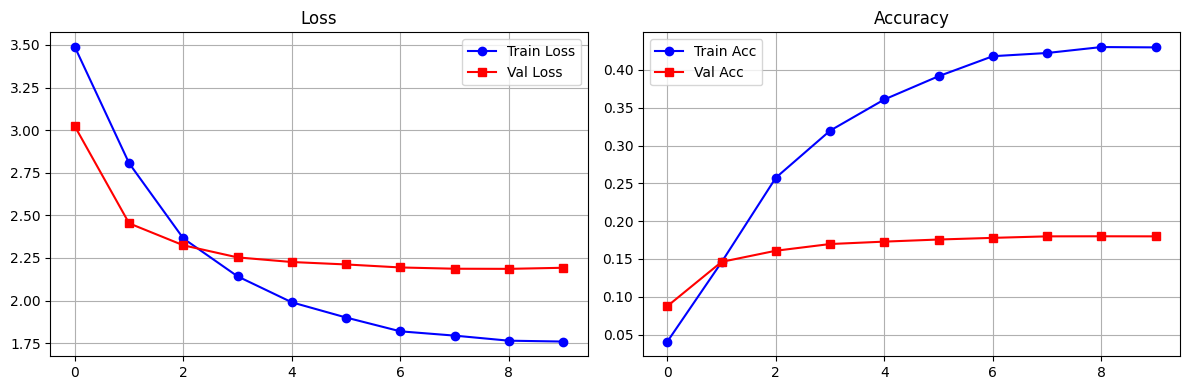

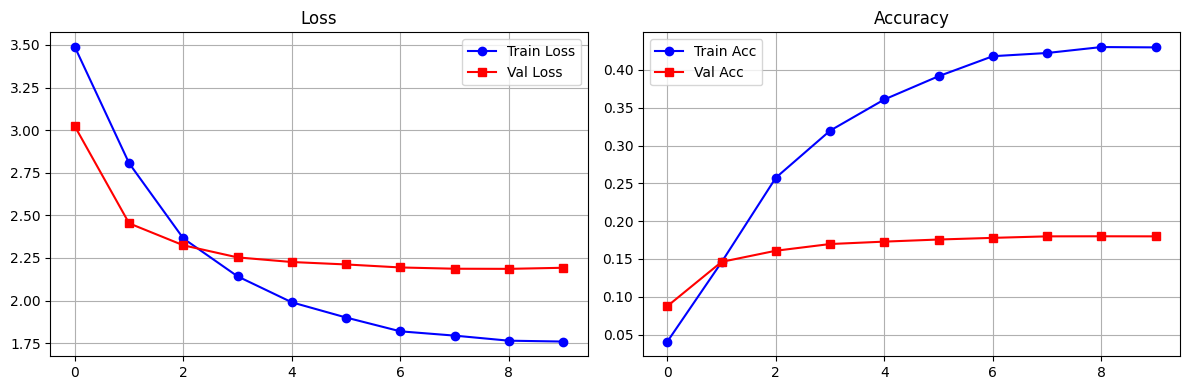


🎉 FINE-TUNING TRAINING COMPLETED!
✅ Enhanced training completed!


In [ ]:
# TRAINING WITH MONITORING & VISUALIZATION


def train_clip_model(model, train_loader, dev_loader, num_epochs, backbone_lr=BACKBONE_LR, head_lr=HEAD_LR,  patience=PATIENCE):
    """
    Main training loop with discriminative learning rates.
    Uses a low learning rate for backbones and a higher one for projection heads.
    """
    print("\n" + "="*60)
    print("🚀 STARTING CLIP TRAINING WITH DISCRIMINATIVE LEARNING RATES")
    print(f"   - Backbone LR: {backbone_lr}\n   - Head LR: {head_lr}")
    print("="*60)

    # --- SETUP OPTIMIZER WITH PARAMETER GROUPS ---
    # Group parameters for different learning rates
    backbone_params = list(model.image_encoder.backbone.parameters()) + list(model.text_encoder.backbone.parameters())
    head_params = list(model.image_encoder.projection.parameters()) + list(model.text_encoder.projection.parameters()) + [model.temperature]

    # Create parameter groups for the optimizer
    param_groups = [
        {'params': backbone_params, 'lr': backbone_lr},
        {'params': head_params, 'lr': head_lr}
    ]

    # Initialize optimizer with these groups and increased weight decay
    optimizer = AdamW(param_groups, weight_decay=WEIGHT_DECAY)
    total_steps = len(train_loader) * num_epochs
    scheduler = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=total_steps // 10, num_training_steps=total_steps)

    # Standard training loop setup
    plt.ion()
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    history = {'train_losses': [], 'val_losses': [], 'train_accuracies': [], 'val_accuracies': [], 'best_val_loss': float('inf')}
    best_val_loss = float('inf')
    patience_counter = 0


    main_pbar = tqdm(range(num_epochs), desc="🚀 Training Progress", position=0)
    for epoch in main_pbar:
        model.train()
        train_loss, train_acc = 0, 0
        train_pbar = tqdm(train_loader, desc=f"📈 Epoch {epoch+1} Train", position=1, leave=False)
        for batch in train_pbar:
            optimizer.zero_grad()
            image_embeddings, text_embeddings = model(
                batch['image'].to(device), batch['input_ids'].to(device), batch['attention_mask'].to(device)
            )
            temp = model.get_temperature()
            loss, acc = contrastive_loss(image_embeddings, text_embeddings, temp)
            loss.backward()
            optimizer.step()
            scheduler.step()

            train_loss += loss.item()
            train_acc += acc.item()
            train_pbar.set_postfix({'Loss': f'{loss.item():.4f}', 'Acc': f'{acc.item():.3f}'})

        history['train_losses'].append(train_loss / len(train_loader))
        history['train_accuracies'].append(train_acc / len(train_loader))


        # --- Validation Phase ---
        model.eval()
        val_loss, val_acc = 0, 0
        with torch.no_grad():
            val_pbar = tqdm(dev_loader, desc=f"📊 Epoch {epoch+1} Val", position=1, leave=False)
            for batch in val_pbar:
                image_embeddings, text_embeddings = model(
                    batch['image'].to(device), batch['input_ids'].to(device), batch['attention_mask'].to(device)
                )
                temp = model.get_temperature()
                loss, acc = contrastive_loss(image_embeddings, text_embeddings, temp)
                val_loss += loss.item()
                val_acc += acc.item()
                val_pbar.set_postfix({'Loss': f'{loss.item():.4f}', 'Acc': f'{acc.item():.3f}'})

        avg_val_loss = val_loss / len(dev_loader)
        history['val_losses'].append(avg_val_loss)
        history['val_accuracies'].append(val_acc / len(dev_loader))

        # --- Live Plotting and Saving ---
        axes[0].clear(); axes[0].plot(history['train_losses'], 'b-o', label='Train Loss'); axes[0].plot(history['val_losses'], 'r-s', label='Val Loss'); axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)
        axes[1].clear(); axes[1].plot(history['train_accuracies'], 'b-o', label='Train Acc'); axes[1].plot(history['val_accuracies'], 'r-s', label='Val Acc'); axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)
        plt.tight_layout(); clear_output(wait=True); display(fig)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            history['best_val_loss'] = best_val_loss
            torch.save(model.state_dict(), 'best_clip_model.pth')
            print(f"🏆 New best model saved! Val Loss: {best_val_loss:.4f}")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"🛑 Early stopping at epoch {epoch+1}")
                break

    plt.ioff(); plt.show()
    print("\n🎉 FINE-TUNING TRAINING COMPLETED!")
    return history



# --- Execute Training ---
if 'train_loader' in locals():
    print("🚀 Starting CLIP model training with live monitoring...")
    # Use global variables for training parameters
    training_history = train_clip_model(
        model, train_loader, dev_loader, num_epochs=NUM_EPOCHS, backbone_lr=BACKBONE_LR, head_lr=HEAD_LR)

    print("✅ Enhanced training completed!")
else:
    print("⚠️ Skipping training because data loaders were not created.")


## 4️⃣ Training Visualization and Performance Analysis

**Task**: Visualize training progress and analyze model convergence.

**Requirements**:
- Plot training and validation loss curves
- Display accuracy progression over epochs  
- Analyze learning dynamics and convergence patterns

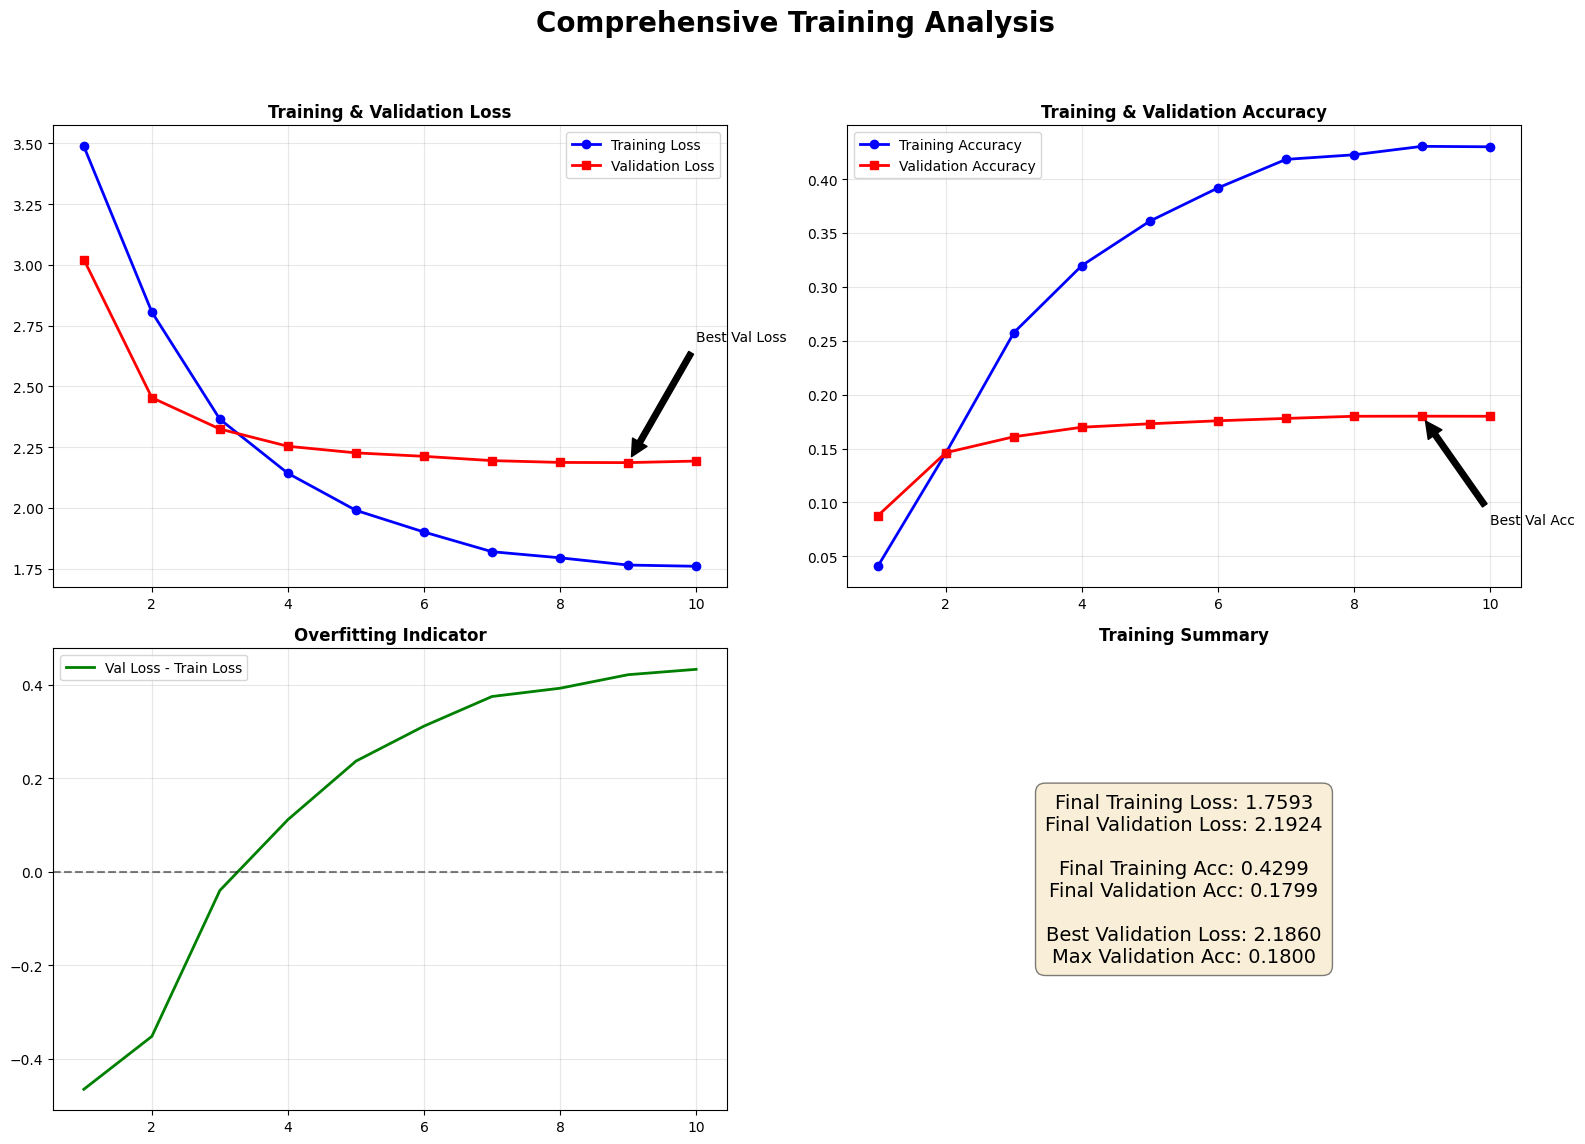

In [ ]:
# TRAINING VISUALIZATION

def plot_training_history(history):
    if not history:
        print("Training history is empty. Cannot plot.")
        return

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Comprehensive Training Analysis', fontsize=20, fontweight='bold')
    epochs = range(1, len(history['train_losses']) + 1)

    # Plot Loss
    axes[0, 0].plot(epochs, history['train_losses'], 'b-o', label='Training Loss', linewidth=2)
    axes[0, 0].plot(epochs, history['val_losses'], 'r-s', label='Validation Loss', linewidth=2)
    axes[0, 0].set_title('Training & Validation Loss', fontweight='bold')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    min_loss_idx = np.argmin(history['val_losses'])
    axes[0, 0].annotate('Best Val Loss', xy=(epochs[min_loss_idx], history['val_losses'][min_loss_idx]),
                        xytext=(epochs[min_loss_idx]+1, history['val_losses'][min_loss_idx]+0.5),
                        arrowprops=dict(facecolor='black', shrink=0.05))

    # Plot Accuracy
    axes[0, 1].plot(epochs, history['train_accuracies'], 'b-o', label='Training Accuracy', linewidth=2)
    axes[0, 1].plot(epochs, history['val_accuracies'], 'r-s', label='Validation Accuracy', linewidth=2)
    axes[0, 1].set_title('Training & Validation Accuracy', fontweight='bold')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    max_acc_idx = np.argmax(history['val_accuracies'])
    axes[0, 1].annotate('Best Val Acc', xy=(epochs[max_acc_idx], history['val_accuracies'][max_acc_idx]),
                        xytext=(epochs[max_acc_idx]+1, history['val_accuracies'][max_acc_idx]-0.1),
                        arrowprops=dict(facecolor='black', shrink=0.05))

    # Plot Overfitting Indicator
    loss_diff = np.array(history['val_losses']) - np.array(history['train_losses'])
    axes[1, 0].plot(epochs, loss_diff, 'g-', linewidth=2, label='Val Loss - Train Loss')
    axes[1, 0].set_title('Overfitting Indicator', fontweight='bold')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axhline(y=0, color='black', linestyle='--', alpha=0.5)

    # Display a text summary
    summary_text = (
        f"Final Training Loss: {history['train_losses'][-1]:.4f}\n"
        f"Final Validation Loss: {history['val_losses'][-1]:.4f}\n\n"
        f"Final Training Acc: {history['train_accuracies'][-1]:.4f}\n"
        f"Final Validation Acc: {history['val_accuracies'][-1]:.4f}\n\n"
        f"Best Validation Loss: {history['best_val_loss']:.4f}\n"
        f"Max Validation Acc: {max(history['val_accuracies']):.4f}"
    )
    axes[1, 1].text(0.5, 0.5, summary_text, ha='center', va='center', fontsize=14, bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))
    axes[1, 1].set_title('Training Summary', fontweight='bold')
    axes[1, 1].axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if 'training_history' in locals() and training_history:
    plot_training_history(training_history)
else:
    print("Training history not available for plotting.")


## 5️⃣ Zero-Shot Classification Implementation

**Task**: Implement and test zero-shot classification capabilities using the trained CLIP model.

**Requirements**:
- Create zero-shot classification function
- Define text prompts for different categories
- Test on sample images from the test set
- Calculate similarities and make predictions
- Visualize classification results with confidence scores

🧪 Testing zero-shot classification...
✅ Loaded best model weights for evaluation.

--- Image 1: 1056338697_4f7d7ce270.jpg ---
Original Caption Example: "A blond woman in a blue shirt appears to wait for a ride ."
🏆 Top Prediction: "a photo of a child" (Probability: 0.464)

--- Image 2: 106490881_5a2dd9b7bd.jpg ---
Original Caption Example: "A boy in his blue swim shorts at the beach ."
🏆 Top Prediction: "a photo of a child" (Probability: 0.822)

--- Image 3: 1082379191_ec1e53f996.jpg ---
Original Caption Example: "A lady and a man with no shirt sit on a dock ."
🏆 Top Prediction: "a photo of a child" (Probability: 0.715)

--- Image 4: 1084040636_97d9633581.jpg ---
Original Caption Example: "A closeup of a white dog that is laying its head on its paws ."
🏆 Top Prediction: "a photo of a dog" (Probability: 0.901)


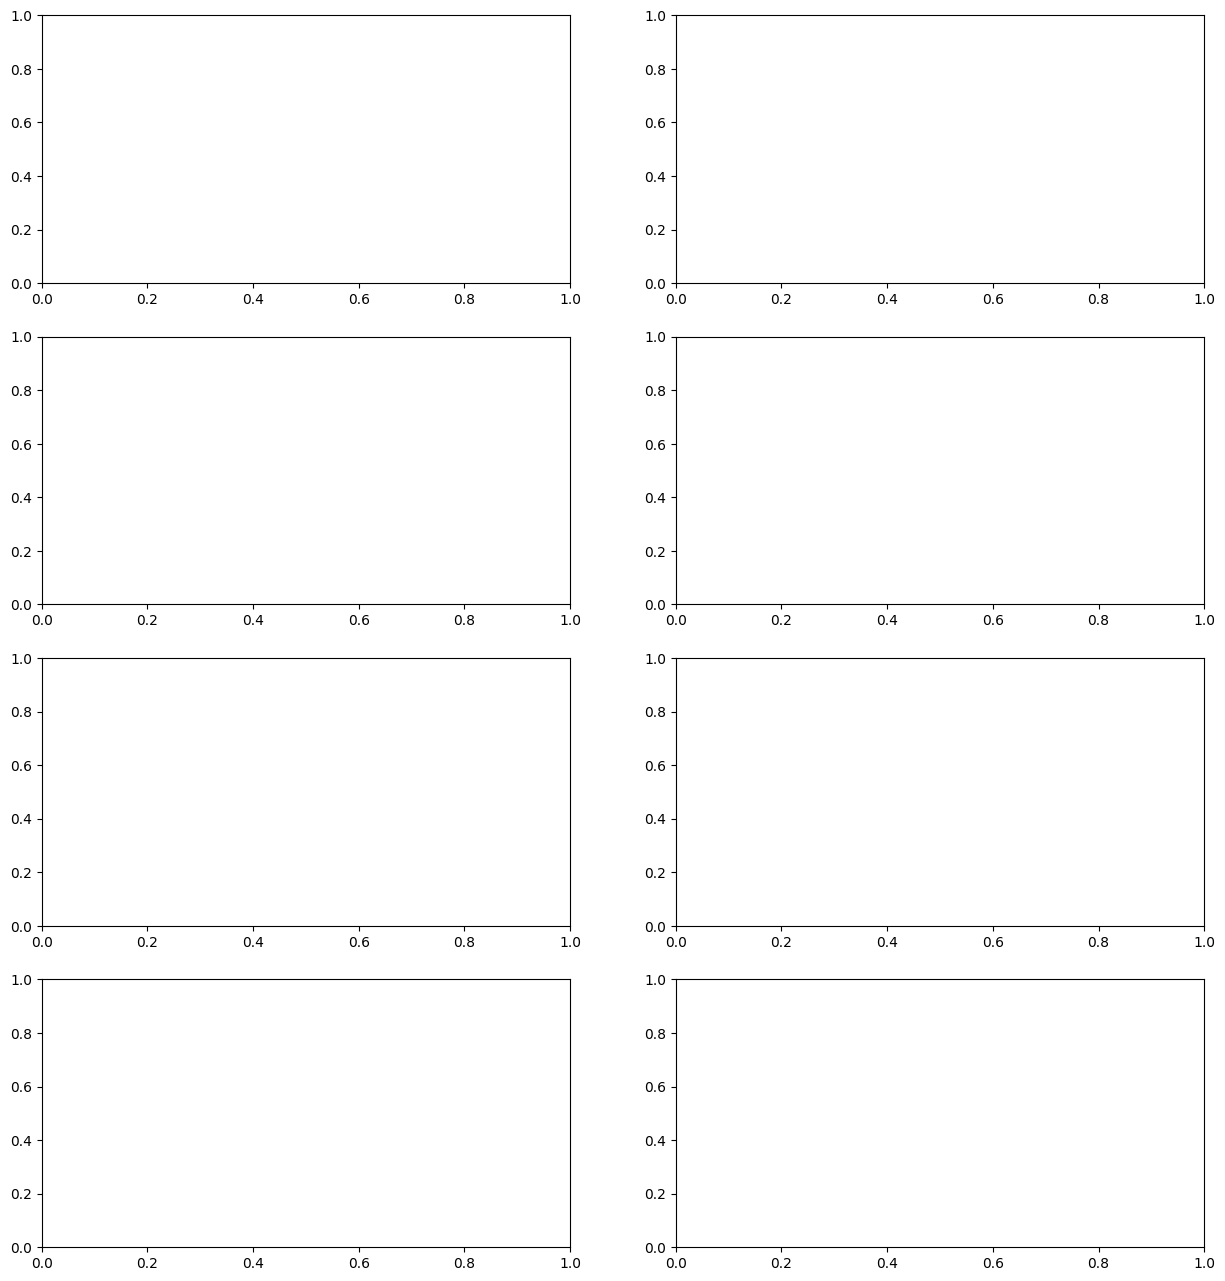

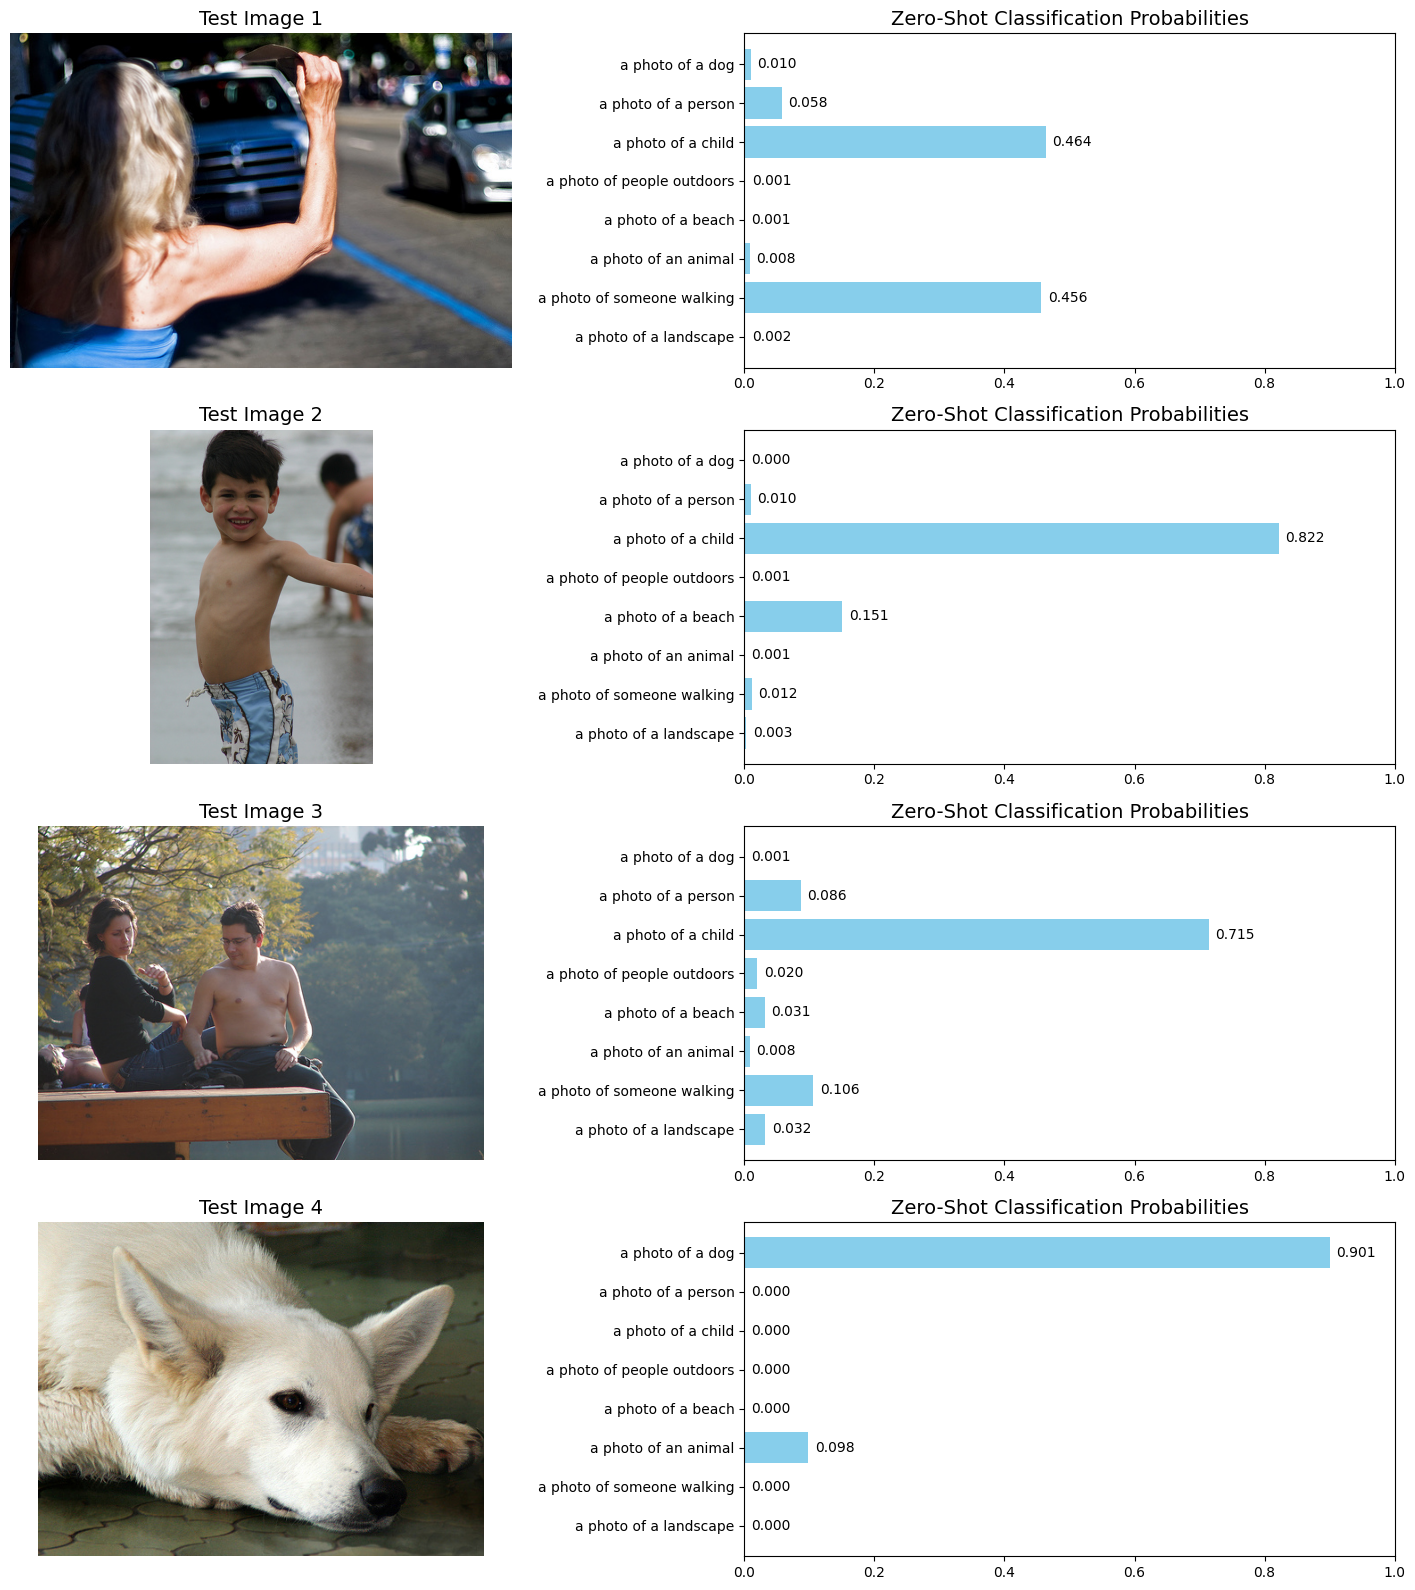

In [ ]:
# ZERO-SHOT CLASSIFICATION

def zero_shot_classification(model, image_pil, text_prompts, tokenizer, transform):
    model.eval()
    with torch.no_grad():
        image_tensor = transform(image_pil).unsqueeze(0).to(device)
        text_tokens = tokenizer(
            text_prompts, padding=True, truncation=True, return_tensors='pt'
        )
        text_input_ids = text_tokens['input_ids'].to(device)
        text_attention_mask = text_tokens['attention_mask'].to(device)
        image_embedding = model.image_encoder(image_tensor)
        text_embeddings = model.text_encoder(text_input_ids, text_attention_mask)
        similarities = torch.matmul(image_embedding, text_embeddings.T).squeeze()
        probabilities = F.softmax(similarities * model.get_temperature(), dim=0)
    return similarities.cpu().numpy(), probabilities.cpu().numpy()

def visualize_zero_shot_results(images, text_prompts, probabilities_list, num_images=4):
    fig, axes = plt.subplots(num_images, 2, figsize=(15, num_images * 4))
    # axes = axes.ravel() if num_images == 1 else axes  # Simplified handling - Removing this line
    idx = 0
    for i in range(min(num_images, len(images))):
        # Display the image on the correct subplot axis
        axes[i, 0].imshow(images[i])
        axes[i, 0].set_title(f'Test Image {i+1}', fontsize=14)
        axes[i, 0].axis('off')

        # Display the probabilities on the correct subplot axis
        probabilities = probabilities_list[i]
        y_pos = np.arange(len(text_prompts))
        bars = axes[i, 1].barh(y_pos, probabilities, color='skyblue')
        axes[i, 1].set_yticks(y_pos)
        axes[i, 1].set_yticklabels(text_prompts)
        axes[i, 1].set_title('Zero-Shot Classification Probabilities', fontsize=14)
        axes[i, 1].set_xlim(0, 1)
        axes[i, 1].invert_yaxis()
        for bar, prob in zip(bars, probabilities):
            axes[i, 1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, f'{prob:.3f}', va='center')
        idx += 1 # This index is no longer needed with direct indexing

    # Remove any unused subplots if num_images is less than the total subplots created
    for j in range(i + 1, num_images):
        fig.delaxes(axes[j, 0])
        fig.delaxes(axes[j, 1])

    plt.tight_layout()
    plt.show()

categories = [
    "a photo of a dog", "a photo of a person", "a photo of a child",
    "a photo of people outdoors", "a photo of a beach", "a photo of an animal",
    "a photo of someone walking", "a photo of a landscape"
]

if 'test_dataset' in locals() and 'model' in locals():
    print("🧪 Testing zero-shot classification...")
    try:
        model.load_state_dict(torch.load('best_clip_model.pth', map_location=device))
        print("✅ Loaded best model weights for evaluation.")
    except FileNotFoundError:
        print("⚠️ Using current model weights ('best_clip_model.pth' not found).")

    test_images, probabilities_results = [], []
    num_unique_images_to_test = 4

    for i in range(num_unique_images_to_test):
        sample_index = i * 5
        if sample_index >= len(test_dataset.data): break
        image_filename, original_caption = test_dataset.data[sample_index]
        image_pil = Image.open(os.path.join(IMAGES_DIR, image_filename)).convert('RGB')
        test_images.append(image_pil)
        _, probabilities = zero_shot_classification(
            model, image_pil, categories, tokenizer, val_transform
        )
        probabilities_results.append(probabilities)
        top_pred_idx = np.argmax(probabilities)
        print(f"\n--- Image {i+1}: {image_filename} ---")
        print(f"Original Caption Example: \"{original_caption}\"")
        print(f"🏆 Top Prediction: \"{categories[top_pred_idx]}\" (Probability: {probabilities[top_pred_idx]:.3f})")

    if test_images:
        visualize_zero_shot_results(test_images, categories, probabilities_results, num_images=len(test_images))
else:
    print("Skipping zero-shot classification because model or test data is not available.")

## 6️⃣ Custom Prompt Testing

**Task**: Test the model with custom text prompts

**Requirements**:
- Create custom text prompts for specific scenarios
- Test model performance on different prompt styles
- Create comprehensive visualization of results


🔬 Testing with more descriptive custom prompts...


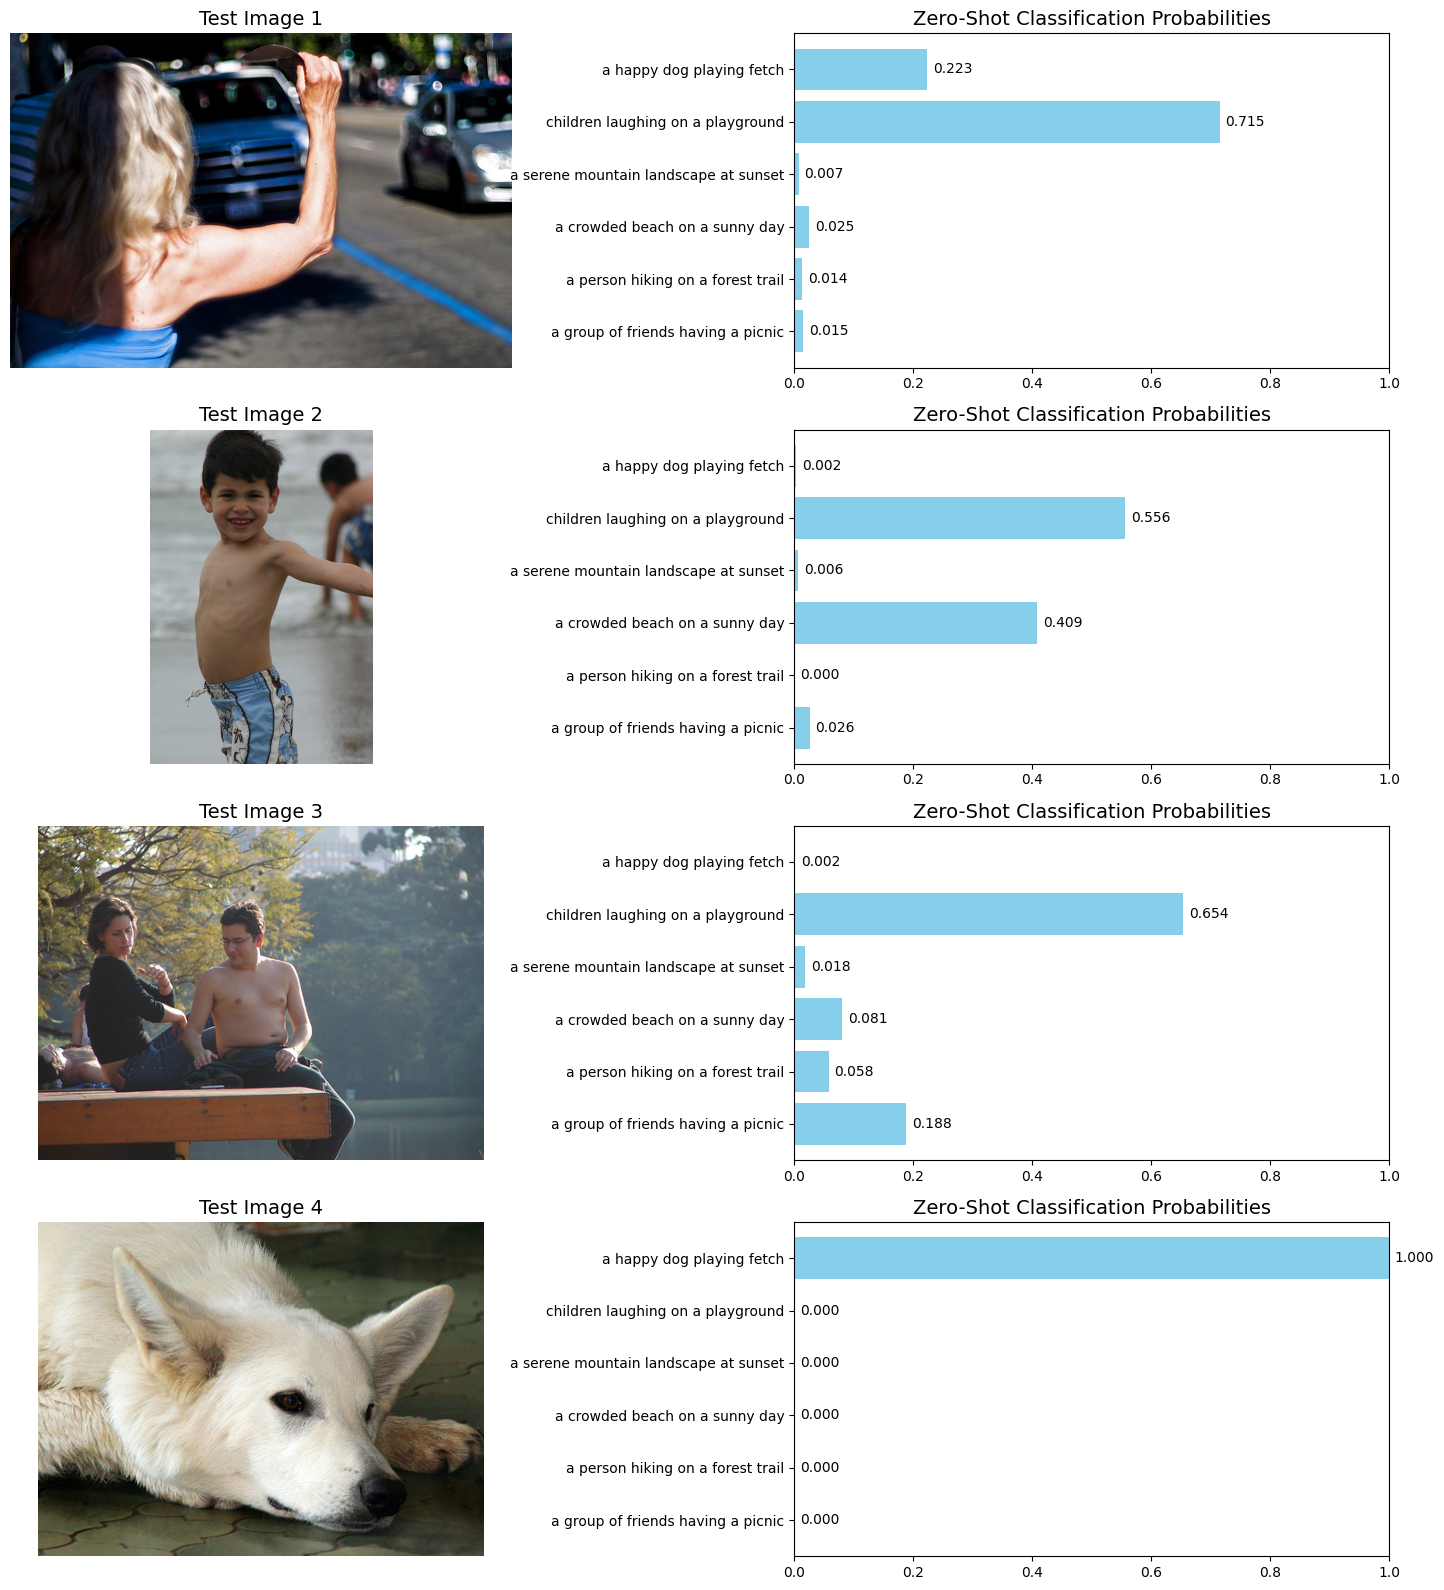


🔎 COMPARISON: Standard vs. Custom Prompts

--- Image 1 ---
  Standard Category: 'a photo of a child' (Conf: 0.464)
  Custom Prompt:     'children laughing on a playground' (Conf: 0.715)

--- Image 2 ---
  Standard Category: 'a photo of a child' (Conf: 0.822)
  Custom Prompt:     'children laughing on a playground' (Conf: 0.556)

--- Image 3 ---
  Standard Category: 'a photo of a child' (Conf: 0.715)
  Custom Prompt:     'children laughing on a playground' (Conf: 0.654)

--- Image 4 ---
  Standard Category: 'a photo of a dog' (Conf: 0.901)
  Custom Prompt:     'a happy dog playing fetch' (Conf: 1.000)


In [ ]:
# CUSTOM PROMPT TESTING

def test_custom_prompts(model, test_images, custom_prompts, tokenizer, transform):
    print("\n🔬 Testing with more descriptive custom prompts...")
    all_probabilities = []
    for i, image in enumerate(test_images):
        _, probabilities = zero_shot_classification(
            model, image, custom_prompts, tokenizer, transform
        )
        all_probabilities.append(probabilities)
    return all_probabilities

custom_prompts = [
    "a happy dog playing fetch", "children laughing on a playground",
    "a serene mountain landscape at sunset", "a crowded beach on a sunny day",
    "a person hiking on a forest trail", "a group of friends having a picnic"
]

if 'test_images' in locals() and test_images and 'model' in locals():
    custom_probabilities = test_custom_prompts(
        model, test_images, custom_prompts, tokenizer, val_transform
    )
    visualize_zero_shot_results(test_images, custom_prompts, custom_probabilities, num_images=len(test_images))

    print("\n" + "="*60 + "\n🔎 COMPARISON: Standard vs. Custom Prompts\n" + "="*60)
    for i in range(len(test_images)):
        std_top_idx = np.argmax(probabilities_results[i])
        custom_top_idx = np.argmax(custom_probabilities[i])
        print(f"\n--- Image {i+1} ---")
        print(f"  Standard Category: '{categories[std_top_idx]}' (Conf: {probabilities_results[i][std_top_idx]:.3f})")
        print(f"  Custom Prompt:     '{custom_prompts[custom_top_idx]}' (Conf: {custom_probabilities[i][custom_top_idx]:.3f})")
else:
    print("Skipping custom prompt testing because test images or model not available.")


In [ ]:


# FINAL SUMMARY OF HYPERPARAMETERS AND METRICS

if 'training_history' in locals() and training_history:
    final_train_loss = training_history['train_losses'][-1]
    final_val_loss = training_history['val_losses'][-1]
    final_train_acc = training_history['train_accuracies'][-1]
    final_val_acc = training_history['val_accuracies'][-1]
    best_val_loss = training_history['best_val_loss']

    print("="*80)
    print("🚀 TRAINING & HYPERPARAMETER SUMMARY 🚀")
    print("="*80)

    print("\n--- Hyperparameters ---")
    print(f"  - Batch Size:          {BATCH_SIZE}")
    print(f"  - Number of Epochs:    {NUM_EPOCHS}")
    print(f"  - Learning Rate (Head):{HEAD_LR:.0e}")
    print(f"  - Learning Rate (Base):{BACKBONE_LR:.0e}")
    print(f"  - Weight Decay:        {WEIGHT_DECAY}")
    print(f"  - Embedding Dimension: {embed_dim}")
    print(f"  - Optimizer:           AdamW")
    print(f"  - Scheduler:           Cosine with Warmup")
    print(f"  - Early Stopping Patience: {PATIENCE}")

    print("\n--- Final Model Metrics ---")
    print(f"  - Best Validation Loss:  {best_val_loss:.4f}")
    print(f"  - Final Train Loss:      {final_train_loss:.4f}")
    print(f"  - Final Validation Loss: {final_val_loss:.4f}")
    print(f"  - Final Train Accuracy:  {final_train_acc:.4f}")
    print(f"  - Final Validation Acc:  {final_val_acc:.4f}")

    print("\n--- Model Architecture ---")
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  - Total Parameters:      {total_params:,}")
    print(f"  - Trainable Parameters:  {trainable_params:,}")

    print("\n" + "="*80)
else:
    print("Could not generate summary as training history is not available.")


🚀 TRAINING & HYPERPARAMETER SUMMARY 🚀

--- Hyperparameters ---
  - Batch Size:          32
  - Number of Epochs:    10
  - Learning Rate (Head):5e-05
  - Learning Rate (Base):5e-07
  - Weight Decay:        0.1
  - Embedding Dimension: 512
  - Optimizer:           AdamW
  - Scheduler:           Cosine with Warmup
  - Early Stopping Patience: 3

--- Final Model Metrics ---
  - Best Validation Loss:  2.1860
  - Final Train Loss:      1.7593
  - Final Validation Loss: 2.1924
  - Final Train Accuracy:  0.4299
  - Final Validation Acc:  0.1799

--- Model Architecture ---
  - Total Parameters:      93,481,793
  - Trainable Parameters:  77,870,657



# Analysis

The purpose of this project was to implement a CLIP (Contrastive Language-Image Pre-training) model from scratch, trained on the Flickr8k dataset to teach it to understand the semantic relationships between the visual content of an image and the meaning of a text caption.

I implemented a dual-encoder atchitecture as described in the original CLIP paper (https://arxiv.org/pdf/2103.00020), with:
-  an image encoder, based in this case on a ResNet50 backkbone pretrained on ImageNet, plus an added projection head to map visual features into a 512-dimensional vector space.
- aa text encoder, based on pretrained DistilBERT model (https://huggingface.co/docs/transformers/model_doc/distilbert), with a projection head to map text into the 512-D vector space.

The dataset used was Flickr8k, which consists of approximately 8000 images, eaach with 5 corresponding captions.

I tried to avoid overfitting with an aggressive data augmentation pipeline for the training set, including geometric, color, and occlusion transform such as random erasing.


The training process was a significant challenge, due to overfitting. I followed an iterative approach to address this issue.

My first major attempt involved unfreezing the pre-trained backbones (ResNet and DistilBERT) to allow for full fine-tuning. I used discriminative learning rates: a low learning rate for the backbones and a higher one for the new projection heads.
The model demonstrated good learning capacity but immediately began to overfit. The training loss plummeted, while the validation loss plateaued almost immediately. This behavior is a classic symptom of overfitting. The model found it easier to "memorize" the training images rather than learn the general rules that would allow it to perform well on the unseen validation data.

Then, I introduced stronger regularization techniques such as increasing the dropout rate in the projection heads to 0.6 and adding a LayerNorm layer to stabilize the activations.

While these techniques slightly slowed the overfitting, the underlying problem remained. The model is still too powerful for the size of the dataset, and its tendency to memorize outweighs its ability to generalize.

Evaluation and Conclusion
I evaluated the model using zero-shot classification tests with both generic prompts ("a photo of a dog") and more descriptive, custom prompts ("a happy dog playing"). The results confirmed what was seen in the training graphs: the model has a basic understanding, but its performance is capped by its inability to generalize effectively.

Future work should consider the use of a larger dataset to provide the model with more data to generalize from.

## 📝 Evaluation Criteria

Your homework will be evaluated based on:

1. **Implementation Correctness (40%)**
   - Proper dual-encoder CLIP architecture
   - Correct contrastive loss implementation
   - Working training loop with proper optimization
   - Accurate zero-shot classification function

2. **Model Performance (30%)**
   - Convergence during training (decreasing loss)
   - Reasonable accuracy on validation set
   - Meaningful zero-shot classification results
   - Effective image-text alignment in embedding space

3. **Code Quality and Analysis (30%)**
   - Clean, readable code with appropriate structure
   - Comprehensive visualizations and analysis
   - Understanding of multimodal learning concepts
   - Insightful interpretation of results

## 🎯 Expected Outcomes
- Train loss should decrease and stabilize
- Validation accuracy should improve over epochs
- Zero-shot classification should show reasonable predictions
- Similarity matrices should reflect semantic relationships
- Model should demonstrate understanding of image-text correspondence